U ovom notebook-u cemo se pozabaviti vizualizacijom rezultata dobijenih u prethodnim. Naravno, kako su nam za prikaze potrebni skupovi u 2 ili 3 dimenzije, zapravo cemo iskoristiti cinjenicu da smo vec pokretali PCA analizu nad skupovima, pa cemo iz njih uzeti najbolja 2 ili 3 atributa i njih iskoristiti za prikaz rezultata klasterovanja u svih 5 algoritama. Zatim cemo sprovesti PCA analizu i nad skupom iz prethodnog notebook-a, gde smo trazili igrace koji mogu predstavljati najbolje investicije za klubove.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.decomposition import PCA

PROCESSED_DIR = Path("../data/processed")
CLUSTERS_DIR = PROCESSED_DIR / "clusters"
RESULTS_DIR = CLUSTERS_DIR / "results"

Ucitacemo skup igraca bez informacija o klubovima i drzavama, a zatim i njegovu PCA verziju. Prva verzija je neophodna kako bismo imali pristup originalnim nazivima atributa

In [23]:
X_before_pca = pd.read_csv(
    CLUSTERS_DIR / "X_no_countries_no_club.csv"
)

X_pca95 = pd.read_csv(
    CLUSTERS_DIR / "X_no_countries_no_club_pca95.csv"
)

print("Pre PCA:", X_before_pca.shape)
print("PCA95:", X_pca95.shape)

Pre PCA: (44905, 114)
PCA95: (44905, 55)


In [24]:
duplicate_columns = [
    col for col in X_before_pca.columns
    if col.endswith(".1")
]

duplicate_columns

['valuation_count.1',
 'avg_valuation.1',
 'min_valuation.1',
 'max_valuation.1',
 'std_valuation.1',
 'first_valuation.1',
 'latest_valuation.1',
 'valuation_growth.1',
 'valuation_growth_pct.1']

In [25]:
original_columns = [
    col[:-2]
    for col in duplicate_columns
]

In [26]:
for original, duplicate in zip(original_columns, duplicate_columns):
    same = X_before_pca[original].equals(
        X_before_pca[duplicate]
    )

    print(f"{original:<35} {same}")

valuation_count                     True
avg_valuation                       True
min_valuation                       True
max_valuation                       True
std_valuation                       True
first_valuation                     True
latest_valuation                    True
valuation_growth                    True
valuation_growth_pct                True


In [27]:
X_before_pca = X_before_pca.drop(
    columns=duplicate_columns
)

print(X_before_pca.shape)

(44905, 105)


In [28]:
[col for col in X_before_pca.columns if col.endswith(".1")]

[]

In [29]:
pca95 = PCA(
    n_components=0.95,
    random_state=42
)

X_pca95_reconstructed = pca95.fit_transform(X_before_pca)

print("Broj PCA komponenti:", pca95.n_components_)
print("Ukupno objašnjena varijansa:", pca95.explained_variance_ratio_.sum())

Broj PCA komponenti: 56
Ukupno objašnjena varijansa: 0.9524562844421012


In [30]:
pca_columns = [
    f"PC{i + 1}"
    for i in range(pca95.n_components_)
]

X_pca95 = pd.DataFrame(
    X_pca95_reconstructed,
    columns=pca_columns,
    index=X_before_pca.index
)

X_pca95.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC47,PC48,PC49,PC50,PC51,PC52,PC53,PC54,PC55,PC56
0,6.524713,-0.266382,4.970007,-0.983846,2.289372,-5.024668,-1.405776,-1.389496,-0.959145,3.090057,...,-0.715496,-0.783746,-0.663149,-0.002464,-0.146885,-0.638169,-0.127984,0.715305,-0.846995,0.849822
1,2.248036,-3.348430,-2.683099,-3.305922,-3.625211,-5.624238,4.033898,-0.057435,-1.181655,-0.497989,...,0.432202,2.056574,1.275638,0.171105,-0.032002,1.140655,0.011454,-0.018425,0.119144,0.090504
2,5.775307,0.782577,3.643357,-0.485313,2.590180,-5.114519,-0.686999,-1.803192,-0.764799,2.470019,...,-1.696967,-0.018663,0.177915,0.160927,-0.418344,-0.090162,-0.310606,1.493881,-1.362600,1.144771
3,0.577129,0.165490,-1.240539,1.399993,2.588546,-3.293248,-0.072800,-0.291716,-1.092309,-0.604060,...,-1.746666,-0.192294,-0.049112,0.211295,-1.279520,0.117419,-0.470356,2.119475,-2.896678,0.586949
4,-1.092957,-0.962536,-1.765583,-2.930019,-3.369897,-4.512244,2.173067,0.845751,-1.125983,0.070380,...,0.394779,0.764513,0.136139,-0.018765,0.779210,-0.073058,0.076515,-0.466096,0.421049,0.104892


In [31]:
explained_variance = pd.DataFrame({
    "component": pca_columns,
    "explained_variance_ratio": pca95.explained_variance_ratio_,
    "cumulative_explained_variance": np.cumsum(
        pca95.explained_variance_ratio_
    )
})

explained_variance.head(10)

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.176409,0.176409
1,PC2,0.059239,0.235647
2,PC3,0.047671,0.283318
3,PC4,0.041675,0.324993
4,PC5,0.039405,0.364398
5,PC6,0.036554,0.400952
6,PC7,0.031510,0.432462
7,PC8,0.028103,0.460565
8,PC9,0.027832,0.488397
9,PC10,0.024683,0.513080


In [32]:
print(
    "Prve dve komponente objašnjavaju:",
    explained_variance.loc[1, "cumulative_explained_variance"]
)

print(
    "Prve tri komponente objašnjavaju:",
    explained_variance.loc[2, "cumulative_explained_variance"]
)

Prve dve komponente objašnjavaju: 0.23564739816658348
Prve tri komponente objašnjavaju: 0.283318255813561


In [33]:
loadings = pd.DataFrame(
    pca95.components_.T,
    index=X_before_pca.columns,
    columns=pca_columns
)

loadings.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC47,PC48,PC49,PC50,PC51,PC52,PC53,PC54,PC55,PC56
age,0.049498,-0.197926,0.047773,0.009752,0.032469,-0.188878,0.019914,0.004186,-0.085297,0.016738,...,0.092900,0.181234,0.077076,-0.007909,0.196547,0.024696,0.019473,-0.153988,0.133117,-0.220660
height_in_cm,-0.002735,-0.020071,-0.155521,-0.181385,-0.056478,-0.131091,-0.100687,-0.128320,-0.036487,0.014564,...,0.061142,0.220616,-0.161061,-0.055272,0.092401,-0.059742,0.026081,-0.009832,0.087567,0.007418
international_caps,0.130780,0.050360,-0.028198,-0.027698,-0.030971,0.049820,0.000506,-0.020274,0.059160,0.009541,...,-0.035776,-0.020197,0.081575,-0.003160,0.150021,-0.070120,0.004725,0.036779,-0.034345,0.138293
international_goals,0.113423,0.101310,0.051484,-0.031974,0.011284,-0.011805,-0.008753,-0.045145,0.056403,0.041215,...,0.047402,0.082081,0.027365,0.005219,-0.095469,0.115409,-0.001701,-0.118264,0.097225,-0.006169
market_value_in_eur,0.137766,0.212106,-0.129917,0.083890,0.048163,-0.035588,-0.016982,0.047345,-0.078630,0.003920,...,0.070217,0.071268,0.039262,-0.000053,0.093192,-0.008881,-0.004438,-0.013164,-0.034128,-0.028823


In [34]:
def get_top_pca_features(
    loadings_df,
    component,
    n_features=15
):
    result = pd.DataFrame({
        "feature": loadings_df.index,
        "loading": loadings_df[component].values,
        "absolute_loading": loadings_df[component].abs().values
    })

    return (
        result
        .sort_values("absolute_loading", ascending=False)
        .head(n_features)
        .reset_index(drop=True)
    )

In [35]:
top_pc1 = get_top_pca_features(
    loadings,
    "PC1",
    n_features=15
)

top_pc1

,feature,loading,absolute_loading
0,matches_played,0.202642,0.202642
1,lineup_count,0.196081,0.196081
2,starter_count,0.194892,0.194892
3,total_minutes,0.194439,0.194439
4,max_valuation,0.194302,0.194302
5,highest_market_value_in_eur,0.194302,0.194302
6,std_valuation,0.190768,0.190768
7,event_substitutions,0.188603,0.188603
8,avg_valuation,0.188450,0.188450
9,total_assists,0.183215,0.183215


In [36]:
top_pc2 = get_top_pca_features(
    loadings,
    "PC2",
    n_features=15
)

top_pc2

,feature,loading,absolute_loading
0,market_value_in_eur,0.212106,0.212106
1,latest_valuation,0.212106,0.212106
2,valuation_growth,0.211893,0.211893
3,avg_minutes,-0.202386,0.202386
4,age,-0.197926,0.197926
5,avg_transfer_fee,0.184324,0.184324
6,max_minutes,-0.184227,0.184227
7,event_cards,-0.182411,0.182411
8,max_transfer_fee,0.181864,0.181864
9,valuation_count,-0.180280,0.180280


In [37]:
top_pc3 = get_top_pca_features(
    loadings,
    "PC3",
    n_features=15
)

top_pc3

,feature,loading,absolute_loading
0,position_Attack,0.303850,0.303850
1,position_Defender,-0.259164,0.259164
2,sub_position_Centre-Back,-0.218347,0.218347
3,pct_as_centre_back,-0.217378,0.217378
4,pct_as_centre_forward,0.201579,0.201579
5,sub_position_Centre-Forward,0.193485,0.193485
6,goals_per_match,0.187997,0.187997
7,games_as_centre_back,-0.175018,0.175018
8,games_as_centre_forward,0.172527,0.172527
9,pct_as_left_winger,0.160747,0.160747


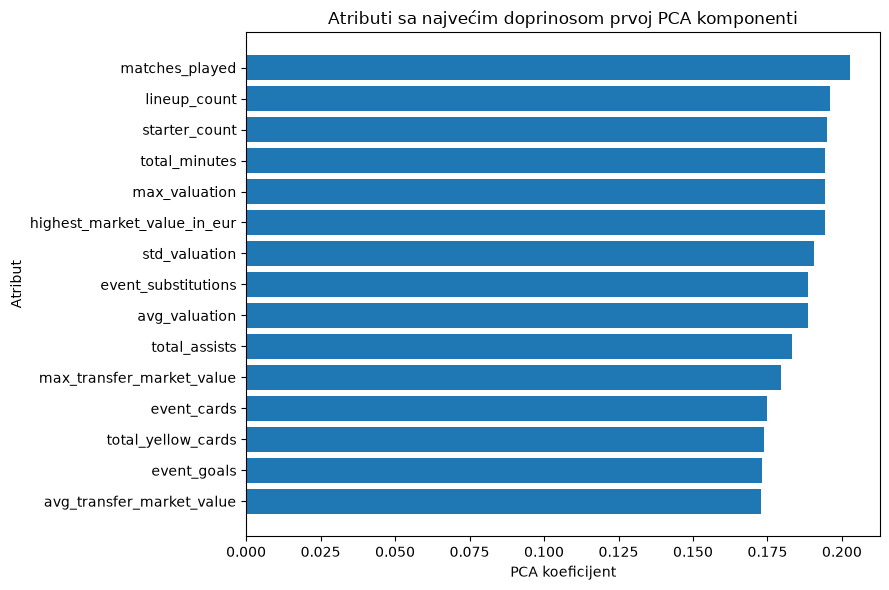

In [38]:
pc1_plot = top_pc1.sort_values("loading")

plt.figure(figsize=(9, 6))

plt.barh(
    pc1_plot["feature"],
    pc1_plot["loading"]
)

plt.xlabel("PCA koeficijent")
plt.ylabel("Atribut")
plt.title("Atributi sa najvećim doprinosom prvoj PCA komponenti")

plt.tight_layout()
plt.show()

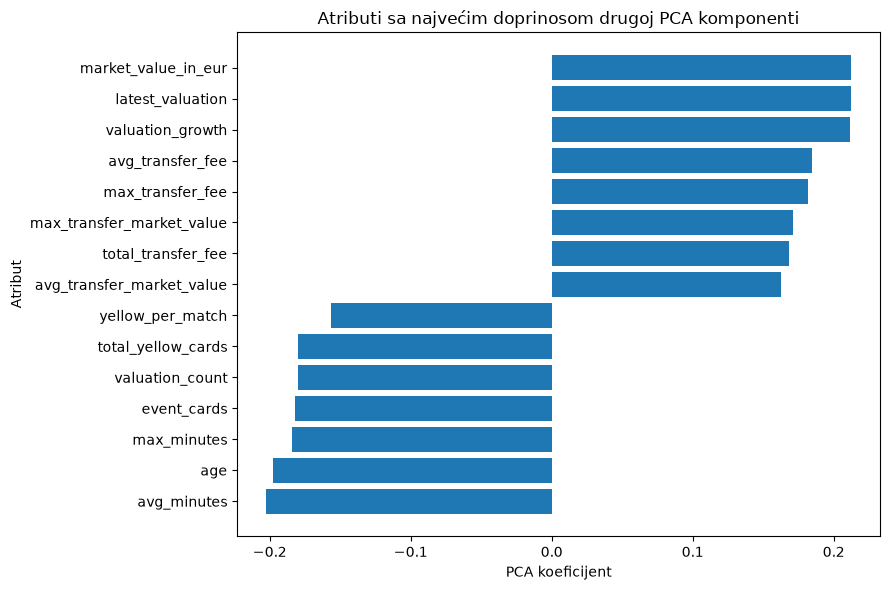

In [39]:
pc2_plot = top_pc2.sort_values("loading")

plt.figure(figsize=(9, 6))

plt.barh(
    pc2_plot["feature"],
    pc2_plot["loading"]
)

plt.xlabel("PCA koeficijent")
plt.ylabel("Atribut")
plt.title("Atributi sa najvećim doprinosom drugoj PCA komponenti")

plt.tight_layout()
plt.show()

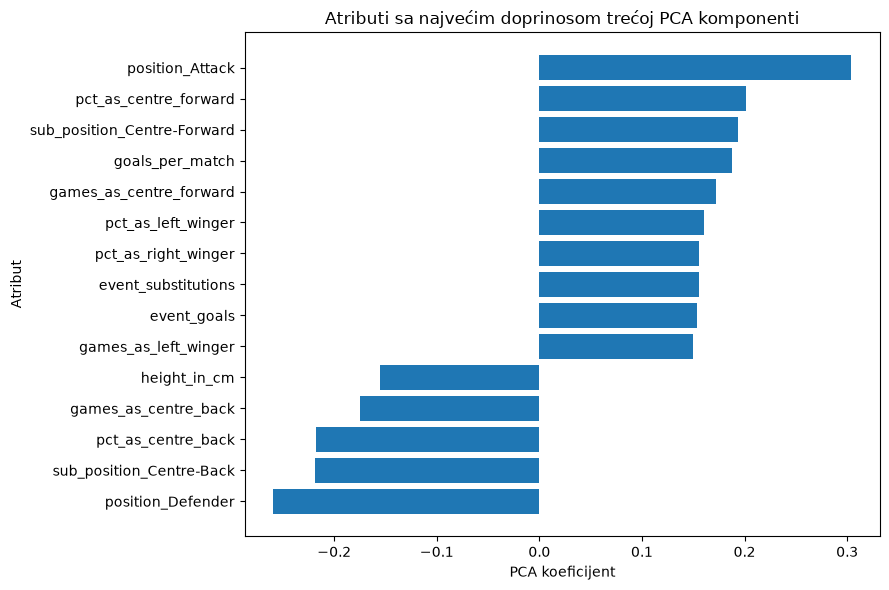

In [40]:
pc3_plot = top_pc3.sort_values("loading")

plt.figure(figsize=(9, 6))

plt.barh(
    pc3_plot["feature"],
    pc3_plot["loading"]
)

plt.xlabel("PCA koeficijent")
plt.ylabel("Atribut")
plt.title("Atributi sa najvećim doprinosom trećoj PCA komponenti")

plt.tight_layout()
plt.show()

U notebook-u broj 04 smo vec pokretali sve algoritme nad ovim skupom, i to sa razlicitim parametrima. Kao najbolji u toj analizi su se pokazali KMeans i hijerarhijsko klasterovanje, oba sa 3 klastera. Iz tog razloga, nema potrebe ponovo pokretati i prikazivati rezultate svih algoritama, vec cemo prikazati samo rad ova dva.

### KMeans sa 3 klastera nad PCA95%

In [41]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_pca95)

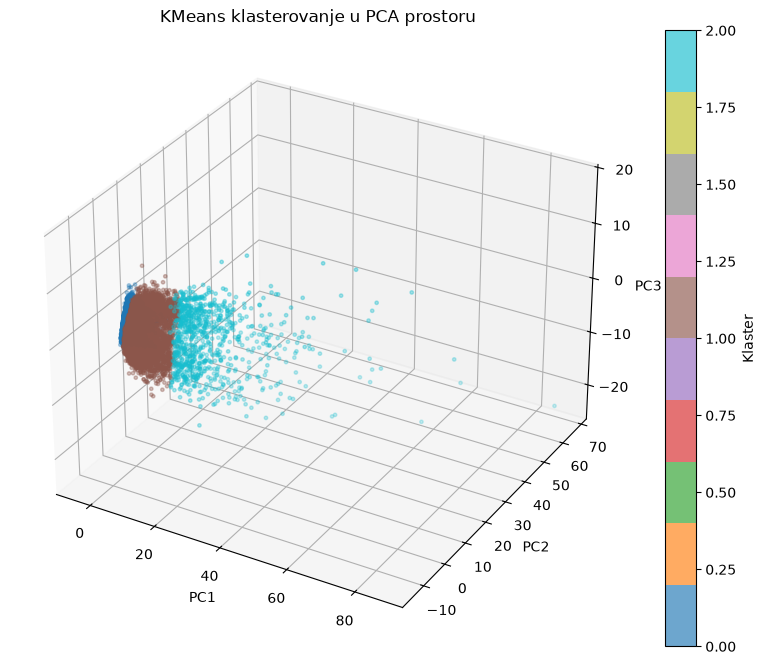

In [42]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    X_pca95["PC1"],
    X_pca95["PC2"],
    X_pca95["PC3"],
    c=kmeans_labels,
    cmap="tab10",
    s=6,
    alpha=0.65
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title("KMeans klasterovanje u PCA prostoru")

plt.colorbar(
    scatter,
    label="Klaster"
)

plt.show()

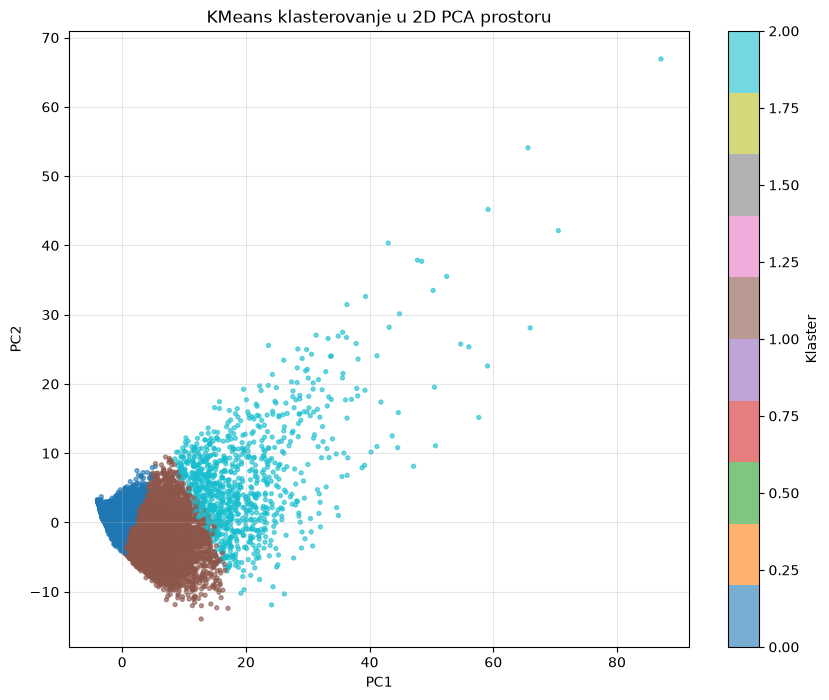

In [43]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_pca95["PC1"],
    X_pca95["PC2"],
    c=kmeans_labels,
    cmap="tab10",
    s=8,
    alpha=0.6
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans klasterovanje u 2D PCA prostoru")

plt.colorbar(
    scatter,
    label="Klaster"
)

plt.grid(alpha=0.3)
plt.show()

### Hijerarhijsko klasterovanje sa 3 klastera nad skupom PCA95%

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.cluster import AgglomerativeClustering

df_meta = pd.read_csv(
    "../data/processed/player_features_full.csv"
)

sample_meta, _ = train_test_split(
    df_meta,
    train_size=10000,
    random_state=42,
    stratify=df_meta["position"]
)

sample_indices = sample_meta.index.to_numpy()

X_pca95_sample = (
    X_pca95
    .iloc[sample_indices]
    .reset_index(drop=True)
)

X_pca95_sample.shape

(10000, 56)

In [45]:
hierarchical = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

hierarchical_labels = hierarchical.fit_predict(
    X_pca95_sample
)

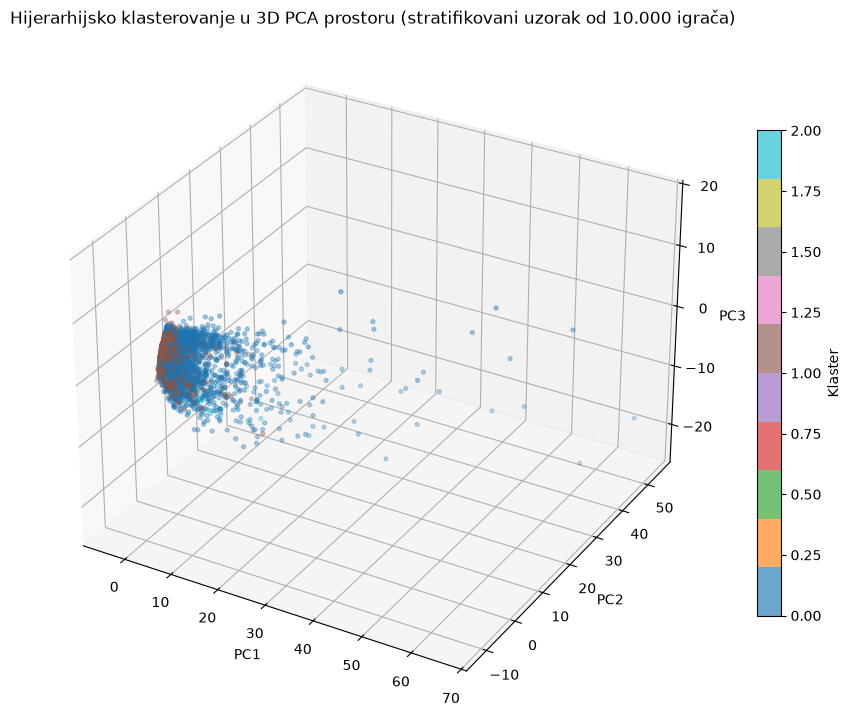

In [46]:
fig = plt.figure(figsize=(11, 9))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    X_pca95_sample["PC1"],
    X_pca95_sample["PC2"],
    X_pca95_sample["PC3"],
    c=hierarchical_labels,
    cmap="tab10",
    s=8,
    alpha=0.65
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title(
    "Hijerarhijsko klasterovanje u 3D PCA prostoru "
    "(stratifikovani uzorak od 10.000 igrača)"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Klaster",
    shrink=0.7
)

plt.show()

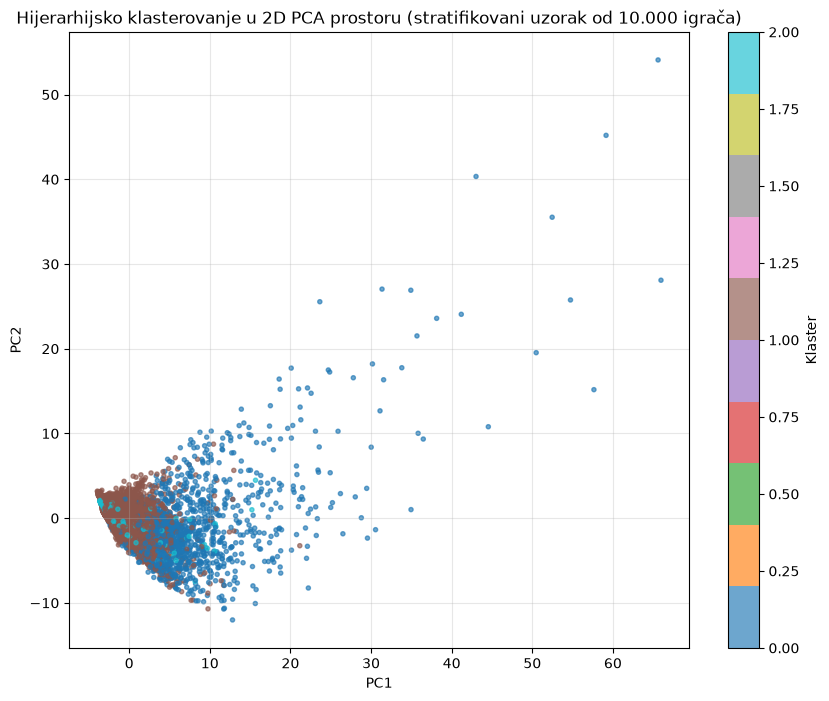

In [47]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_pca95_sample["PC1"],
    X_pca95_sample["PC2"],
    c=hierarchical_labels,
    cmap="tab10",
    s=9,
    alpha=0.65
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "Hijerarhijsko klasterovanje u 2D PCA prostoru "
    "(stratifikovani uzorak od 10.000 igrača)"
)

plt.colorbar(
    scatter,
    label="Klaster"
)

plt.grid(alpha=0.3)
plt.show()

Sada cemo primeniti PCA analizu nad skupom dobijenim u prethodnom notebook-u, a zatim cemo ponovo pokrenuti algoritme KMeans i hijerarhijskog klasterovanja i prikazati njihove rezultate.

In [48]:
X_vfm = pd.read_csv(
    CLUSTERS_DIR / "X_value_for_money.csv"
)

print(X_vfm.shape)

(44905, 66)


Ovaj skup je vec skaliran pa mozemo odmah preci na PCA analizu

In [49]:
pca_all = PCA()
pca_all.fit(X_vfm)

cumulative_variance = np.cumsum(
    pca_all.explained_variance_ratio_
)

for threshold in [0.90, 0.95, 0.99]:
    n_components = (
        np.argmax(cumulative_variance >= threshold)
        + 1
    )

    print(
        f"{threshold:.0%} varijanse -> "
        f"{n_components} komponenti"
    )

90% varijanse -> 30 komponenti
95% varijanse -> 37 komponenti
99% varijanse -> 49 komponenti


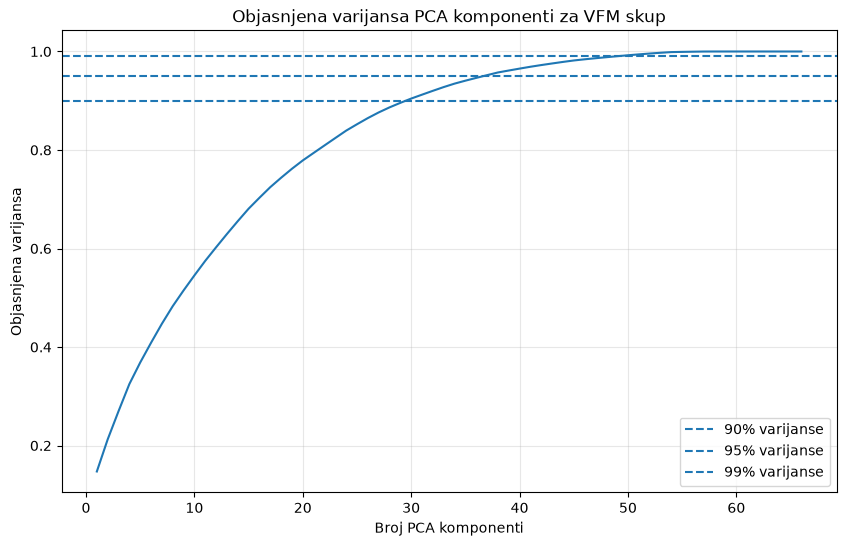

In [50]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% varijanse"
)

plt.axhline(
    y=0.95,
    linestyle="--",
    label="95% varijanse"
)

plt.axhline(
    y=0.99,
    linestyle="--",
    label="99% varijanse"
)

plt.xlabel("Broj PCA komponenti")
plt.ylabel("Objasnjena varijansa")
plt.title("Objasnjena varijansa PCA komponenti za VFM skup")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

Na osnovu prikazanih rezultata, izabracemo skup sa 95% sacuvane varijanse. Razlog za tako nesto je taj sto 7 dodatnih atributa na njih 30 nije dovoljno smanjenje dimenzija kako bismo se odrekli 5% varijanse i izabrali skup sa 90%.

In [51]:
pca_vfm = PCA(
    n_components=0.95,
    random_state=42
)

X_vfm_pca_array = pca_vfm.fit_transform(
    X_vfm
)

pca_columns = [
    f"PC{i + 1}"
    for i in range(pca_vfm.n_components_)
]

X_vfm_pca = pd.DataFrame(
    X_vfm_pca_array,
    columns=pca_columns,
    index=X_vfm.index
)

print(X_vfm_pca.shape)
print(
    "Ukupno objasnjena varijansa:",
    pca_vfm.explained_variance_ratio_.sum()
)

(44905, 37)
Ukupno objasnjena varijansa: 0.9519543256127515


In [52]:
X_vfm_pca.to_csv(
    CLUSTERS_DIR / "X_value_for_money_pca95.csv",
    index=False
)

In [53]:
explained_variance_vfm = pd.DataFrame({
    "component": pca_columns,
    "explained_variance_ratio":
        pca_vfm.explained_variance_ratio_,
    "cumulative_explained_variance":
        np.cumsum(
            pca_vfm.explained_variance_ratio_
        )
})

explained_variance_vfm.head(10)

,component,explained_variance_ratio,cumulative_explained_variance
0,PC1,0.147281,0.147281
1,PC2,0.065167,0.212448
2,PC3,0.057215,0.269663
3,PC4,0.055145,0.324808
4,PC5,0.043728,0.368536
5,PC6,0.040067,0.408603
6,PC7,0.038599,0.447202
7,PC8,0.035710,0.482913
8,PC9,0.031934,0.514846
9,PC10,0.030527,0.545374


In [54]:
print(
    "Prve dve komponente objasnjavaju:",
    explained_variance_vfm.loc[
        1,
        "cumulative_explained_variance"
    ]
)

print(
    "Prve tri komponente objasnjavaju:",
    explained_variance_vfm.loc[
        2,
        "cumulative_explained_variance"
    ]
)

Prve dve komponente objasnjavaju: 0.2124477486130202
Prve tri komponente objasnjavaju: 0.26966309000692884


In [55]:
loadings_vfm = pd.DataFrame(
    pca_vfm.components_.T,
    index=X_vfm.columns,
    columns=pca_columns
)

loadings_vfm.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC28,PC29,PC30,PC31,PC32,PC33,PC34,PC35,PC36,PC37
age,0.121112,-0.074946,0.017468,0.000879,0.173605,-0.141984,-0.266903,0.029304,-0.005049,0.055225,...,-0.289223,-0.057208,-0.414540,-0.254207,0.047413,0.526958,0.076758,-0.126502,0.174513,0.114461
height_in_cm,0.000422,-0.160608,-0.242369,0.053142,0.108304,0.043253,-0.000283,-0.225596,0.025960,0.000387,...,0.122525,0.105673,0.615733,-0.436008,-0.014570,0.423601,0.039077,-0.021904,0.044016,-0.016568
international_caps,0.157190,0.044178,-0.050176,0.031359,-0.142055,0.117247,0.180535,-0.027315,0.018204,0.034761,...,-0.052893,0.237718,0.093656,0.145614,-0.034305,-0.037271,0.068930,-0.238367,0.389138,-0.079261
international_goals,0.124365,0.112713,-0.060484,0.001940,-0.113753,0.113093,0.125993,-0.044580,0.042866,0.120067,...,-0.013298,-0.040108,-0.042883,-0.007933,0.004758,0.109014,-0.229683,0.148939,-0.139697,-0.012546
matches_played,0.300806,-0.013349,-0.031048,0.043003,-0.059406,0.044078,-0.021700,0.025857,-0.017405,0.036269,...,-0.016226,0.005495,0.022961,-0.047263,0.003073,-0.061795,-0.007286,-0.075279,0.006408,0.024043


In [56]:
def get_top_pca_features(
    loadings_df,
    component,
    n_features=15
):
    result = pd.DataFrame({
        "feature": loadings_df.index,
        "loading": loadings_df[component].values,
        "absolute_loading":
            loadings_df[component].abs().values
    })

    return (
        result
        .sort_values(
            "absolute_loading",
            ascending=False
        )
        .head(n_features)
        .reset_index(drop=True)
    )

In [57]:
top_vfm_pc1 = get_top_pca_features(
    loadings_vfm,
    "PC1",
    n_features=15
)

top_vfm_pc1

,feature,loading,absolute_loading
0,matches_played,0.300806,0.300806
1,lineup_count,0.294567,0.294567
2,total_minutes,0.292939,0.292939
3,starter_count,0.292428,0.292428
4,total_yellow_cards,0.268747,0.268747
5,total_assists,0.244642,0.244642
6,max_minutes,0.231657,0.231657
7,substitute_count,0.229126,0.229126
8,total_goals,0.219301,0.219301
9,avg_minutes,0.213628,0.213628


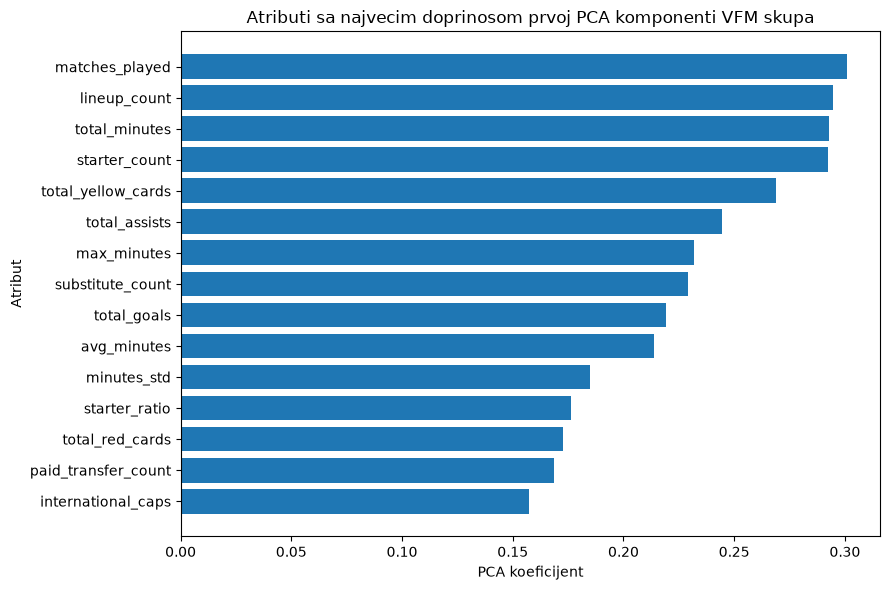

In [60]:
pc1_plot = top_vfm_pc1.sort_values("loading")

plt.figure(figsize=(9, 6))

plt.barh(
    pc1_plot["feature"],
    pc1_plot["loading"]
)

plt.xlabel("PCA koeficijent")
plt.ylabel("Atribut")
plt.title(
    "Atributi sa najvecim doprinosom "
    "prvoj PCA komponenti VFM skupa"
)

plt.tight_layout()
plt.show()

In [58]:
top_vfm_pc2 = get_top_pca_features(
    loadings_vfm,
    "PC2",
    n_features=15
)

top_vfm_pc2

,feature,loading,absolute_loading
0,position_Attack,0.375705,0.375705
1,position_Defender,-0.357208,0.357208
2,sub_position_Centre-Back,-0.284343,0.284343
3,pct_as_centre_back,-0.283162,0.283162
4,pct_as_centre_forward,0.243668,0.243668
5,sub_position_Centre-Forward,0.240962,0.240962
6,pct_as_left_winger,0.191015,0.191015
7,goals_per_match,0.185344,0.185344
8,pct_as_right_winger,0.185343,0.185343
9,sub_position_Left Winger,0.165165,0.165165


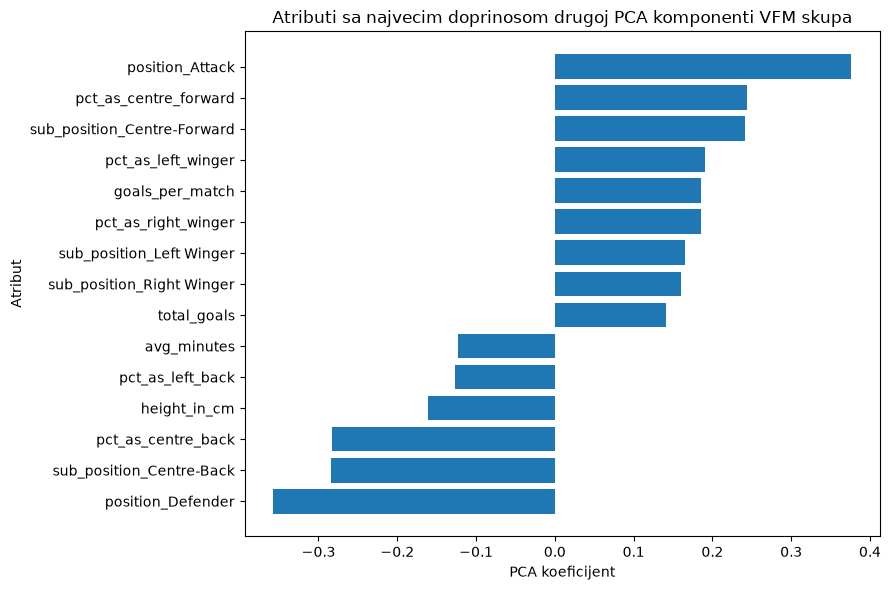

In [61]:
pc2_plot = top_vfm_pc2.sort_values("loading")

plt.figure(figsize=(9, 6))

plt.barh(
    pc2_plot["feature"],
    pc2_plot["loading"]
)

plt.xlabel("PCA koeficijent")
plt.ylabel("Atribut")
plt.title(
    "Atributi sa najvecim doprinosom "
    "drugoj PCA komponenti VFM skupa"
)

plt.tight_layout()
plt.show()

In [59]:
top_vfm_pc3 = get_top_pca_features(
    loadings_vfm,
    "PC3",
    n_features=15
)

top_vfm_pc3

,feature,loading,absolute_loading
0,position_Midfield,0.377572,0.377572
1,sub_position_Goalkeeper,-0.357555,0.357555
2,position_Goalkeeper,-0.357555,0.357555
3,pct_as_goalkeeper,-0.346440,0.346440
4,height_in_cm,-0.242369,0.242369
5,pct_as_central_midfield,0.239853,0.239853
6,sub_position_Central Midfield,0.223336,0.223336
7,pct_as_defensive_midfield,0.194417,0.194417
8,sub_position_Defensive Midfield,0.175150,0.175150
9,pct_as_attacking_midfield,0.162914,0.162914


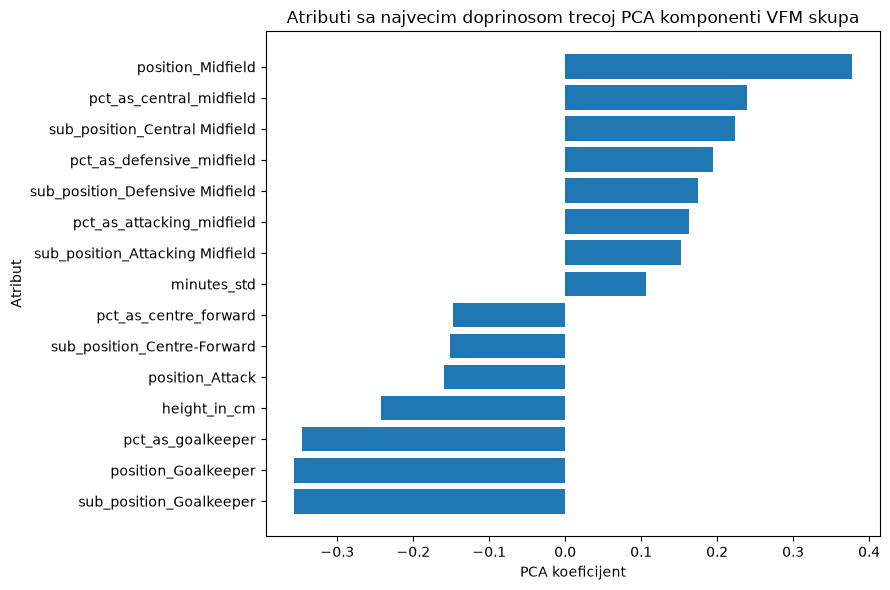

In [62]:
pc3_plot = top_vfm_pc3.sort_values("loading")

plt.figure(figsize=(9, 6))

plt.barh(
    pc3_plot["feature"],
    pc3_plot["loading"]
)

plt.xlabel("PCA koeficijent")
plt.ylabel("Atribut")
plt.title(
    "Atributi sa najvecim doprinosom "
    "trecoj PCA komponenti VFM skupa"
)

plt.tight_layout()
plt.show()

### KMeans

In [63]:
from sklearn.cluster import KMeans

kmeans_vfm_pca = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels_kmeans_vfm_pca = (
    kmeans_vfm_pca.fit_predict(
        X_vfm_pca
    )
)

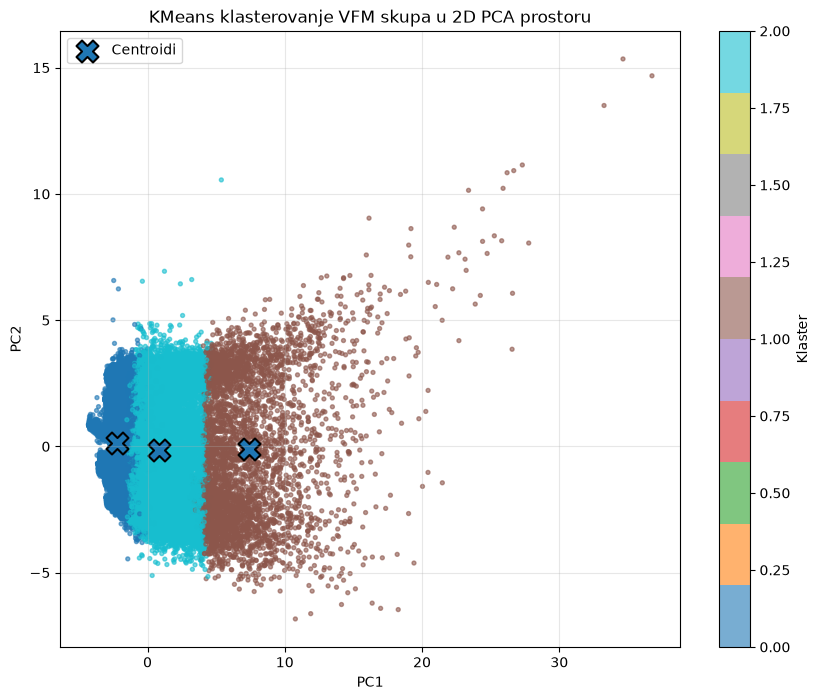

In [64]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_vfm_pca["PC1"],
    X_vfm_pca["PC2"],
    c=labels_kmeans_vfm_pca,
    cmap="tab10",
    s=8,
    alpha=0.6
)

centroids = kmeans_vfm_pca.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=250,
    edgecolors="black",
    linewidths=1.5,
    label="Centroidi"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "KMeans klasterovanje VFM skupa "
    "u 2D PCA prostoru"
)

plt.colorbar(
    scatter,
    label="Klaster"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

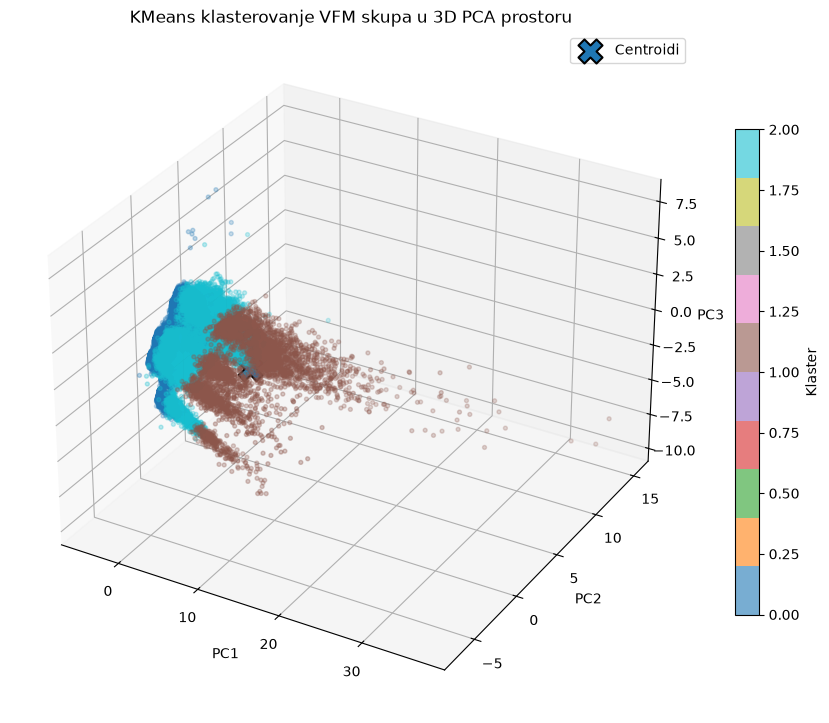

In [65]:
fig = plt.figure(figsize=(11, 9))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    X_vfm_pca["PC1"],
    X_vfm_pca["PC2"],
    X_vfm_pca["PC3"],
    c=labels_kmeans_vfm_pca,
    cmap="tab10",
    s=8,
    alpha=0.6
)

ax.scatter(
    centroids[:, 0],
    centroids[:, 1],
    centroids[:, 2],
    marker="X",
    s=300,
    edgecolors="black",
    linewidths=1.5,
    label="Centroidi"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title(
    "KMeans klasterovanje VFM skupa "
    "u 3D PCA prostoru"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Klaster",
    shrink=0.7
)

ax.legend()

plt.show()

Ponovo uzimamo uzorak od 10000 instanci zbog memorijskih zahteva aglomerativnog hijerarhijskog klasterovanja.

In [66]:
sample_meta, _ = train_test_split(
    df_meta,
    train_size=10000,
    random_state=42,
    stratify=df_meta["position"]
)

sample_indices = sample_meta.index.to_numpy()

X_vfm_pca_sample = (
    X_vfm_pca
    .iloc[sample_indices]
    .reset_index(drop=True)
)

X_vfm_pca_sample.shape

(10000, 37)

In [67]:
hierarchical_vfm_pca = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels_hierarchical_vfm_pca = (
    hierarchical_vfm_pca.fit_predict(
        X_vfm_pca_sample
    )
)

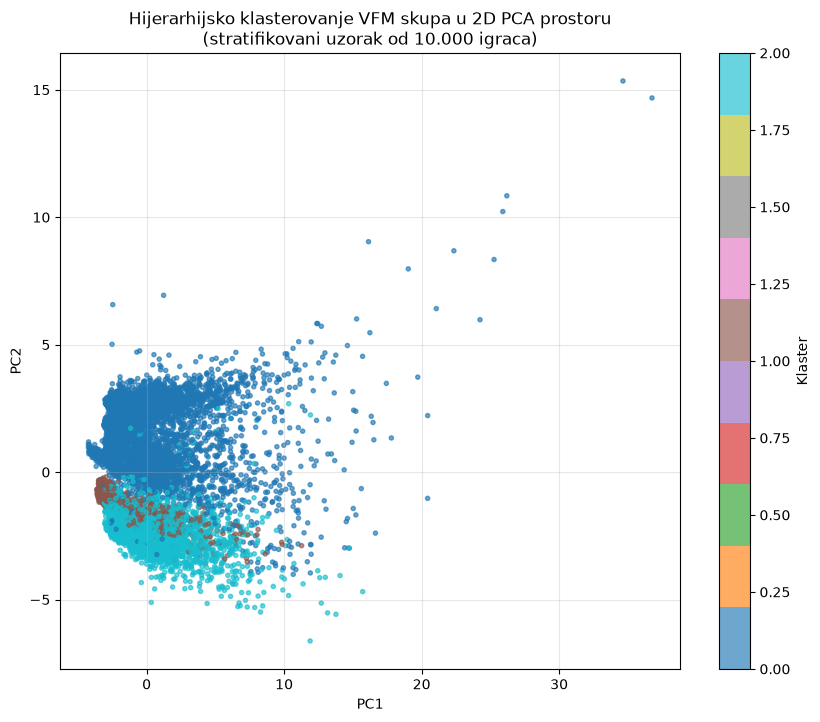

In [68]:
plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_vfm_pca_sample["PC1"],
    X_vfm_pca_sample["PC2"],
    c=labels_hierarchical_vfm_pca,
    cmap="tab10",
    s=9,
    alpha=0.65
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(
    "Hijerarhijsko klasterovanje VFM skupa "
    "u 2D PCA prostoru\n"
    "(stratifikovani uzorak od 10.000 igraca)"
)

plt.colorbar(
    scatter,
    label="Klaster"
)

plt.grid(alpha=0.3)
plt.show()

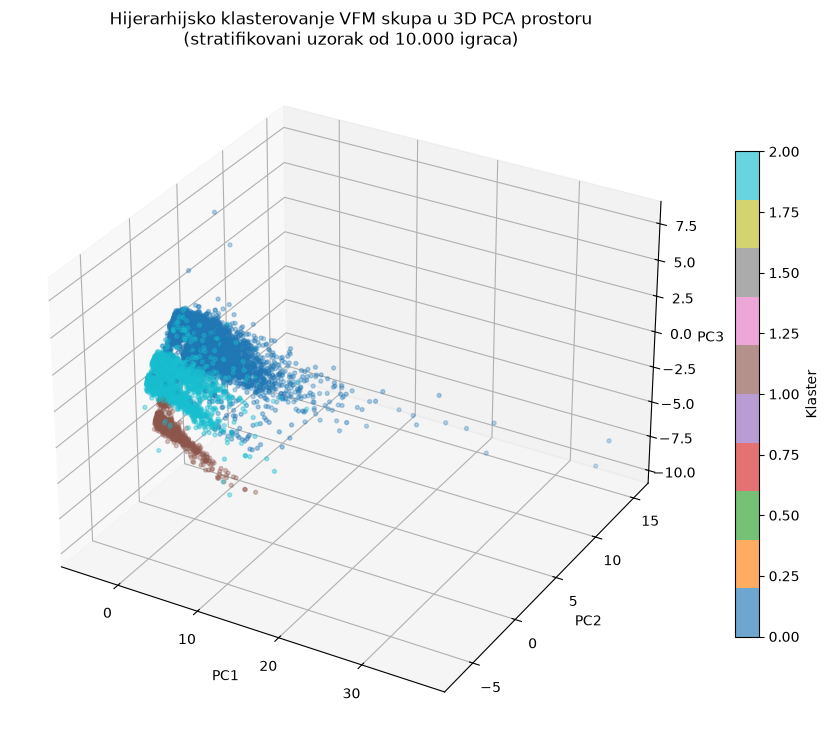

In [69]:
fig = plt.figure(figsize=(11, 9))

ax = fig.add_subplot(
    111,
    projection="3d"
)

scatter = ax.scatter(
    X_vfm_pca_sample["PC1"],
    X_vfm_pca_sample["PC2"],
    X_vfm_pca_sample["PC3"],
    c=labels_hierarchical_vfm_pca,
    cmap="tab10",
    s=8,
    alpha=0.65
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

ax.set_title(
    "Hijerarhijsko klasterovanje VFM skupa "
    "u 3D PCA prostoru\n"
    "(stratifikovani uzorak od 10.000 igraca)"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Klaster",
    shrink=0.7
)

plt.show()